<h1 style="color:#ffffff; background-color:#0D1B2A; text-align:center; font-weight:bold; padding:16px 10px; border-radius:8px; margin-bottom:6px;">Week 5 — Day 3: Dimensionality Reduction with PCA</h1>
<p style="color:#ffffff; background-color:#0072B2; text-align:center; font-weight:bold; font-style:italic; padding:6px 10px; border-radius:6px; margin-top:0; font-size:15px;">Compressing Many Features Into a Few, Without Losing the Story</p>

<a id="toc"></a>
<h2 style="color:#ffffff; background-color:#0072B2; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">Table of Contents</h2>
<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</a></li>
<li><a href="#section1">1. The Curse of Dimensionality</a></li>
<li><a href="#section2">2. What PCA Does</a></li>
<li><a href="#section3">3. Explained Variance</a></li>
<li><a href="#section4">4. When (and When Not) to Use PCA</a></li>
<li><a href="#section5">5. Common Mistakes to Avoid</a></li>
<li><a href="#section6">6. Quick Reference</a></li>
<li><a href="#section7">7. Hands-On Lab — Reducing Dimensions with PCA</a></li>
<li><a href="#section8">8. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section9">9. Summary — What I Learned Today</a></li>
</ol>
</div>

<a id="section0"></a>
<h2 style="color:#ffffff; background-color:#0072B2; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</h2>
<div style="border-left:5px solid #0072B2; background-color:#EAF3FA; padding:10px 15px; margin:10px 0; border-radius:4px; color:#063B66;">
<b>Note:</b> Yesterday's clustering worked on 5 numeric clinical features. Today's PCA lab deliberately uses <b>every</b> feature in the dataset (numeric and categorical, one-hot encoded) so we actually have "too many dimensions" to visualize directly — the exact situation PCA is built for.
</div>

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "4"
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

print("Pandas version      :", pd.__version__)
print("NumPy version       :", np.__version__)
print("Scikit-learn version:", sklearn.__version__)

Pandas version      : 2.3.3
NumPy version       : 2.3.5
Scikit-learn version: 1.7.2


<a id="section1"></a>
<h2 style="color:#ffffff; background-color:#0072B2; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">1. The Curse of Dimensionality</h2>
Real datasets often have dozens or hundreds of features. High dimensionality causes real problems: data becomes <b>sparse</b> (points spread thin across a huge space), <b>distances lose meaning</b> (everything ends up roughly equally far from everything else), models <b>overfit more easily</b>, and you simply <b>cannot visualize</b> more than 3 dimensions at once.

<b>Dimensionality reduction</b> compresses many features into a few, keeping as much information as possible while making data easier to model and to look at.

In [2]:
# A tiny illustration of sparsity: as dimensions grow, points spread further apart
rng = np.random.default_rng(42)

for n_dims in [2, 10, 50, 200]:
    points = rng.random((100, n_dims))
    # average distance from the first point to every other point
    avg_dist = np.linalg.norm(points - points[0], axis=1).mean()
    print(f"{n_dims:>4} dimensions  ->  average distance between points: {avg_dist:.2f}")

   2 dimensions  ->  average distance between points: 0.46
  10 dimensions  ->  average distance between points: 1.35
  50 dimensions  ->  average distance between points: 2.83
 200 dimensions  ->  average distance between points: 5.64


<div style="border-left:5px solid #0072B2; background-color:#EAF3FA; padding:10px 15px; margin:10px 0; border-radius:4px; color:#063B66;">
<b>Note:</b> Notice the average distance keeps climbing as dimensions increase, even though every coordinate is still just a random number between 0 and 1. This is exactly the effect that makes distance-based methods (like K-Means or DBSCAN from Days 1-2) struggle once there are too many features.
</div>

<a id="section2"></a>
<h2 style="color:#ffffff; background-color:#0072B2; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">2. What PCA Does</h2>
<h3 style="color:#E69F00; font-weight:bold; background-color:#1C1C1C; display:inline-block; padding:4px 10px; border-radius:6px;">2.1 Finding the directions of greatest spread</h3>
<b>Principal Component Analysis (PCA)</b> finds new axes — called <b>principal components</b> — that capture the directions of greatest variance in the data. The first component captures the most variance, the second captures the next most (at a right angle to the first), and so on. By keeping only the first few components, you reduce dimensions while retaining most of the information. Each component is a <b>combination</b> of the original features, built on the same linear-algebra ideas from Week 2.

In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# X_scaled = StandardScaler().fit_transform(X)   # PCA requires scaled data
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

print("We will fit PCA on the heart-disease dataset in Section 7.")

We will fit PCA on the heart-disease dataset in Section 7.


<div style="border-left:5px solid #D55E00; background-color:#FDEEE4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A3410;">
<b>Important:</b> PCA requires scaled data, because it is variance-based: an unscaled large-range feature (like <code>Cholesterol</code>, which ranges into the hundreds) would appear artificially more "important" than a small-range feature (like <code>Oldpeak</code>). Always run <code>StandardScaler</code> first — the same discipline from Days 1 and 2.
</div>

<a id="section3"></a>
<h2 style="color:#ffffff; background-color:#0072B2; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">3. Explained Variance</h2>
The key output of PCA is the <b>explained variance ratio</b> — how much of the data's total information each component keeps. Summing these tells you how much information you retained after reduction. A common rule of thumb is to keep enough components to retain around <b>95%</b> of the variance.

In [4]:
# print(pca.explained_variance_ratio_)        # variance kept per component
# print(pca.explained_variance_ratio_.sum())   # total variance retained across all kept components

print("We will compute and plot cumulative explained variance in Section 7.")

We will compute and plot cumulative explained variance in Section 7.


<div style="border-left:5px solid #0072B2; background-color:#EAF3FA; padding:10px 15px; margin:10px 0; border-radius:4px; color:#063B66;">
<b>Note:</b> Think of explained variance like a savings account: the first component is the biggest deposit, the second is a smaller one, and so on. The <b>cumulative</b> explained variance is your running balance — you keep adding components until the balance crosses whatever threshold (often 95%) you decided was "enough."
</div>

<a id="section4"></a>
<h2 style="color:#ffffff; background-color:#0072B2; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">4. When (and When Not) to Use PCA</h2>
PCA has three main uses:

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#0072B2; color:#ffffff;"><th style="padding:8px; text-align:left;">Use</th><th style="padding:8px; text-align:left;">What It Does For You</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Speed &amp; stability</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Fewer input features means faster training and a more stable model.</td></tr>
<tr style="background-color:#F2F2F2;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Reduce overfitting</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Removing redundant / correlated features reduces noise a model could latch onto.</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Visualization</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Reducing data to 2D or 3D lets you actually plot and look at it.</td></tr>
</table></div>

<div style="border-left:5px solid #009E73; background-color:#E9F7F3; padding:10px 15px; margin:10px 0; border-radius:4px; color:#04503B;">
<b>Tip:</b> The trade-off: the new components are <b>combinations</b> of the original features, so they lose the direct interpretability the original columns had. "Principal Component 1" does not mean anything on its own the way <code>Age</code> or <code>Cholesterol</code> does — you trade interpretability for compactness.
</div>

<a id="section5"></a>
<h2 style="color:#ffffff; background-color:#0072B2; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">5. Common Mistakes to Avoid</h2>
<div style="border-left:5px solid #D55E00; background-color:#FDEEE4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A3410;">
<b>Important:</b> <ul>
<li><b>Running PCA on unscaled data</b> — a high-range feature will dominate the first component just because of its scale, not because it is actually more informative.</li>
<li><b>Chasing 100% variance</b> — keeping every component defeats the purpose of reduction; a component with almost no explained variance is usually just noise.</li>
<li><b>Treating principal components as if they were still the original features</b> — Component 1 is a mix of many columns; you cannot say "Component 1 means high cholesterol."</li>
<li><b>Using PCA on a dataset that is mostly one-hot encoded categories</b> — dummy variables are not naturally correlated the way continuous measurements are, so PCA may compress them far less than you expect (you will see this directly in today's lab).</li>
<li><b>Forgetting that PCA is unsupervised</b> — it optimizes for variance, not for separating any particular target class, so components are not guaranteed to be useful for a downstream classification task.</li>
</ul>
</div>

<a id="section6"></a>
<h2 style="color:#ffffff; background-color:#0072B2; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">6. Quick Reference</h2>

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#0072B2; color:#ffffff;"><th style="padding:8px; text-align:left;">Task</th><th style="padding:8px; text-align:left;">Code</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Import PCA &amp; scaler</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;"><code>from sklearn.decomposition import PCA</code><br><code>from sklearn.preprocessing import StandardScaler</code></td></tr>
<tr style="background-color:#F2F2F2;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Scale first (always)</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;"><code>X_scaled = StandardScaler().fit_transform(X)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Fit PCA keeping all components</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;"><code>pca = PCA(n_components=X_scaled.shape[1])</code></td></tr>
<tr style="background-color:#F2F2F2;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Variance kept per component</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;"><code>pca.explained_variance_ratio_</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Running total of variance kept</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;"><code>np.cumsum(pca.explained_variance_ratio_)</code></td></tr>
<tr style="background-color:#F2F2F2;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Reduce to exactly 2 components</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;"><code>PCA(n_components=2).fit_transform(X_scaled)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Auto-pick components for 95%</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;"><code>PCA(n_components=0.95).fit_transform(X_scaled)</code></td></tr>
</table></div>

<a id="section7"></a>
<h2 style="color:#ffffff; background-color:#0072B2; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">7. Hands-On Lab — Reducing Dimensions with PCA</h2>
<div style="border-left:5px solid #CC79A7; background-color:#FAEEF3; padding:10px 15px; margin:10px 0; border-radius:4px; color:#6B2A46;">
<b>Goal:</b> Reduce the heart-disease dataset — all 11 input features, numeric and categorical — down to a handful of principal components. Find out how many components are needed to keep ~95% of the information, then compress all the way down to 2D so we can actually plot it, and check whether the reduction still visually separates patients with and without heart disease.
</div>

<h3 style="color:#E69F00; font-weight:bold; background-color:#1C1C1C; display:inline-block; padding:4px 10px; border-radius:6px;">7.0 Loading, cleaning, and preparing the dataset</h3>
This lab reuses <code>heart.csv</code> from Day 2 — 918 patient records with 11 clinical input features plus a <code>HeartDisease</code> label. Unlike Day 2, we now use <b>all</b> the input features, including the categorical ones (<code>Sex</code>, <code>ChestPainType</code>, <code>RestingECG</code>, <code>ExerciseAngina</code>, <code>ST_Slope</code>), one-hot encoded into numeric columns — this is what gives us a genuinely "high-dimensional" dataset to reduce.

In [5]:
df = pd.read_csv("heart.csv")
print("Shape:", df.shape)
df.head()

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<div style="border-left:5px solid #D55E00; background-color:#FDEEE4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A3410;">
<b>Important:</b> <b>Data quality check (same issue as Day 2):</b> this dataset encodes some missing clinical readings as <code>0</code>, which is not medically real for <code>RestingBP</code> or <code>Cholesterol</code>. Left as-is, these zeros would distort PCA just as badly as they would distort clustering. We treat them as missing and impute with the median before doing anything else.
</div>

In [6]:
print("Zero values found (treated as missing):")
print((df[["RestingBP", "Cholesterol"]] == 0).sum())

X = df.drop(columns=["HeartDisease"]).copy()
for col in ["RestingBP", "Cholesterol"]:
    X[col] = X[col].replace(0, np.nan)
    X[col] = X[col].fillna(X[col].median())

print()
print("Remaining zeros after cleaning:")
print((X[["RestingBP", "Cholesterol"]] == 0).sum())

Zero values found (treated as missing):
RestingBP        1
Cholesterol    172
dtype: int64

Remaining zeros after cleaning:
RestingBP      0
Cholesterol    0
dtype: int64


In [7]:
# One-hot encode the categorical columns so every feature is numeric
X_encoded = pd.get_dummies(X, drop_first=True)

print("Original feature count :", X.shape[1])
print("Encoded feature count  :", X_encoded.shape[1])
X_encoded.head()

Original feature count : 11
Encoded feature count  : 15


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,True,False,True,False,True,False,False,False,True


<h3 style="color:#E69F00; font-weight:bold; background-color:#1C1C1C; display:inline-block; padding:4px 10px; border-radius:6px;">Step 1 — Scale the high-dimensional dataset with StandardScaler</h3>

In [8]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_encoded)
print("Scaled shape:", X_scaled.shape)

Scaled shape: (918, 15)


<h3 style="color:#E69F00; font-weight:bold; background-color:#1C1C1C; display:inline-block; padding:4px 10px; border-radius:6px;">Step 2 — Fit PCA and plot the cumulative explained variance</h3>

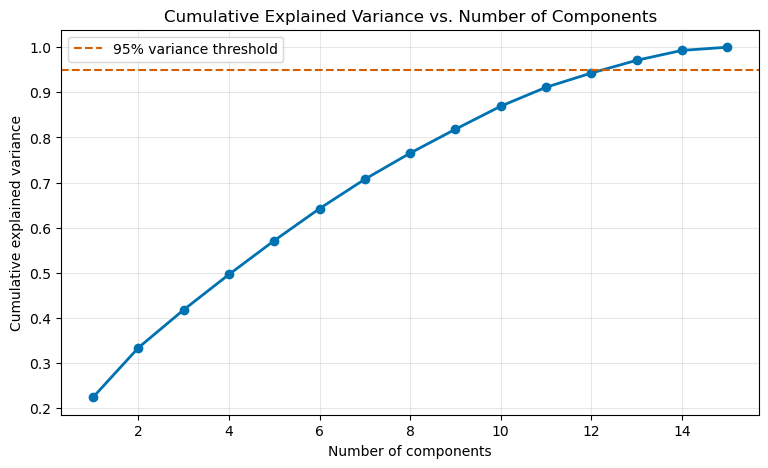

In [9]:
from sklearn.decomposition import PCA

pca_full = PCA(n_components=X_scaled.shape[1], random_state=42)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
         marker="o", color="#0072B2", linewidth=2)
plt.axhline(y=0.95, color="#D55E00", linestyle="--", label="95% variance threshold")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative Explained Variance vs. Number of Components")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<h3 style="color:#E69F00; font-weight:bold; background-color:#1C1C1C; display:inline-block; padding:4px 10px; border-radius:6px;">Step 3 — Choose the number of components that retains ~95% of the variance</h3>

In [10]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Components needed for 95% variance : {n_components_95} out of {X_scaled.shape[1]}")
print(f"Variance retained at that point     : {cumulative_variance[n_components_95 - 1]:.3f}")
print(f"Variance retained by 2 components   : {cumulative_variance[1]:.3f}")

Components needed for 95% variance : 13 out of 15
Variance retained at that point     : 0.971
Variance retained by 2 components   : 0.334


<div style="border-left:5px solid #0072B2; background-color:#EAF3FA; padding:10px 15px; margin:10px 0; border-radius:4px; color:#063B66;">
<b>Note:</b> Notice this dataset needs <b>most</b> of its components to reach 95% variance — nowhere near the dramatic 100-columns-down-to-3 compression PCA gets famous for. This is realistic and worth understanding why: the one-hot encoded categorical columns (like the four <code>ChestPainType</code> dummies) are not strongly correlated with each other or with the numeric columns, so PCA has little redundancy to squeeze out. PCA compresses best on <b>continuous, correlated</b> measurements — it is a poorer fit for datasets that are mostly independent categorical flags, which is exactly the "when not to use PCA" lesson from Section 4.
</div>

<h3 style="color:#E69F00; font-weight:bold; background-color:#1C1C1C; display:inline-block; padding:4px 10px; border-radius:6px;">Step 4 — Reduce to 2 components and visualize, colored by diagnosis</h3>

In [11]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Variance retained by each of the 2 components:", np.round(pca_2d.explained_variance_ratio_, 3))
print("Total variance retained in 2D:", round(pca_2d.explained_variance_ratio_.sum(), 3))

Variance retained by each of the 2 components: [0.224 0.11 ]
Total variance retained in 2D: 0.334


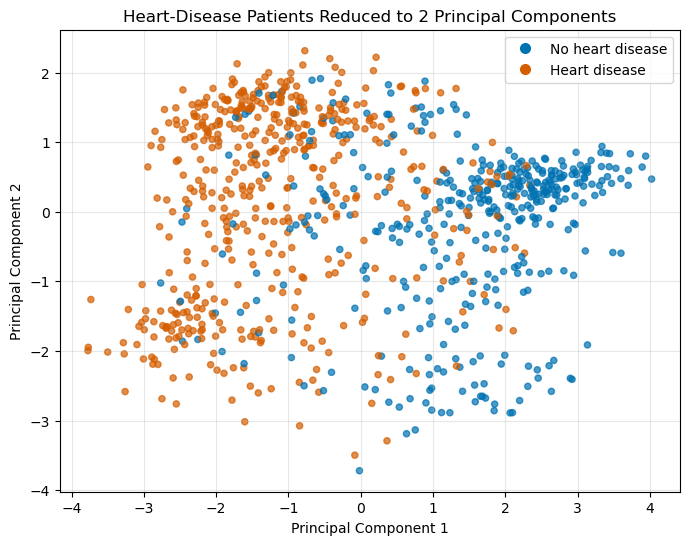

In [12]:
# Colorblind-safe, high-contrast pair: Okabe-Ito blue vs. vermillion (never rely on color alone --
# the legend labels the two groups explicitly).
colors = np.where(df["HeartDisease"] == 1, "#D55E00", "#0072B2")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=colors, s=20, alpha=0.7)

# Build an explicit legend (color alone is never enough to convey meaning)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label="No heart disease",
           markerfacecolor="#0072B2", markersize=9),
    Line2D([0], [0], marker="o", color="w", label="Heart disease",
           markerfacecolor="#D55E00", markersize=9),
]
plt.legend(handles=legend_elements)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Heart-Disease Patients Reduced to 2 Principal Components")
plt.grid(alpha=0.3)
plt.show()

<h3 style="color:#E69F00; font-weight:bold; background-color:#1C1C1C; display:inline-block; padding:4px 10px; border-radius:6px;">Step 5 — Document what the reduction preserved and what it cost</h3>

<div style="border-left:5px solid #D55E00; background-color:#FDEEE4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A3410;">
<b>Final Notes</b><br>
Reducing all 15 encoded features down to just 2 principal components keeps only about a third of the dataset's total variance, and the two diagnosis groups overlap heavily in the 2D scatter plot rather than forming clean, separated clouds. That is an honest, useful result: it tells us this dataset's structure is <b>not</b> dominated by one or two strong directions of variance the way a cleaner, more correlated dataset might be.<br><br>What the reduction <b>preserved</b>: a rough 2D layout we can actually plot and look at, capturing the single strongest pattern of variation across all patients.<br>What it <b>cost</b>: roughly two-thirds of the original information, and any direct interpretability — "Component 1" is a blend of age, cholesterol, chest-pain type, and several other columns, not any one clinical measurement on its own.<br><br>For a task that actually needs to <b>classify</b> heart disease, keeping more components (or skipping PCA and using the original features with a supervised model, as in Weeks 3-4) would likely work better than forcing a 2D compression. Today's 2 components are best understood as a visualization tool, not a finished feature set.
</div>

<a id="section8"></a>
<h2 style="color:#ffffff; background-color:#0072B2; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">8. Best Practices &amp; Reproducibility</h2>
<div style="border-left:5px solid #D55E00; background-color:#FDEEE4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A3410;">
<b>Important:</b> <ul>
<li>Always scale features with <code>StandardScaler</code> before PCA — it is a variance-based method, so scale matters even more here than in clustering.</li>
<li>Check the cumulative explained variance plot before picking a component count — do not default to "2, because I can plot it" if the task does not actually require visualization.</li>
<li>Remember principal components are combinations of the original features — do not try to interpret Component 1 as if it were a single original column.</li>
<li>If a label exists (like <code>HeartDisease</code> here), it is fine to color a PCA plot by it <b>afterward</b> for interpretation — but PCA itself never sees the label, exactly like clustering in Days 1-2.</li>
<li>Fix a random seed (<code>random_state=42</code>) wherever PCA or any other randomized step is used, so results are reproducible for your mentor.</li>
</ul>
</div>

<a id="section9"></a>
<h2 style="color:#ffffff; background-color:#0072B2; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">9. Summary — What I Learned Today</h2>
<div style="border-left:5px solid #009E73; background-color:#E9F7F3; padding:10px 15px; margin:10px 0; border-radius:4px; color:#04503B;">
<b>Tip:</b> <ul>
<li>High-dimensional data causes real problems: sparsity, meaningless distances, and easier overfitting — this is the <b>curse of dimensionality</b>.</li>
<li><b>PCA</b> finds new axes (principal components) that capture the directions of greatest variance, letting you keep only the first few and discard the rest.</li>
<li>The <b>explained variance ratio</b> tells you how much information each component keeps; the cumulative sum is what you check against a target like 95%.</li>
<li>PCA trades <b>interpretability</b> for <b>compactness</b> — components are combinations of the original features, not the features themselves.</li>
<li>PCA compresses best on <b>continuous, correlated</b> data; today's mixed numeric + one-hot-encoded dataset needed far more components than a textbook example would, which is a realistic and important lesson on its own.</li>
<li>Tomorrow, <b>Day 4</b> moves to <b>t-SNE</b> for visualization and <b>Isolation Forest</b> for anomaly detection — two more ways to make sense of data that has no labels.</li>
</ul>
</div>